In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

import warnings
warnings.filterwarnings("ignore")

In [2]:
tsla = pd.read_csv("../data/processed/TSLA_processed.csv")

tsla["Date"] = pd.to_datetime(tsla["Date"])

tsla.set_index("Date", inplace=True)

tsla.head()

,Adj Close,Close,High,Low,Open,Volume,Daily Return,Rolling Mean,Rolling Std
Date,,,,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000,NaN,NaN,NaN
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500,-0.042041,NaN,NaN
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500,0.005664,NaN,NaN
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000,-0.001562,NaN,NaN
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500,-0.001564,NaN,NaN


In [3]:
data = tsla["Close"]

data.head()

Date
2015-01-02    14.620667
2015-01-05    14.006000
2015-01-06    14.085333
2015-01-07    14.063333
2015-01-08    14.041333
Name: Close, dtype: float64

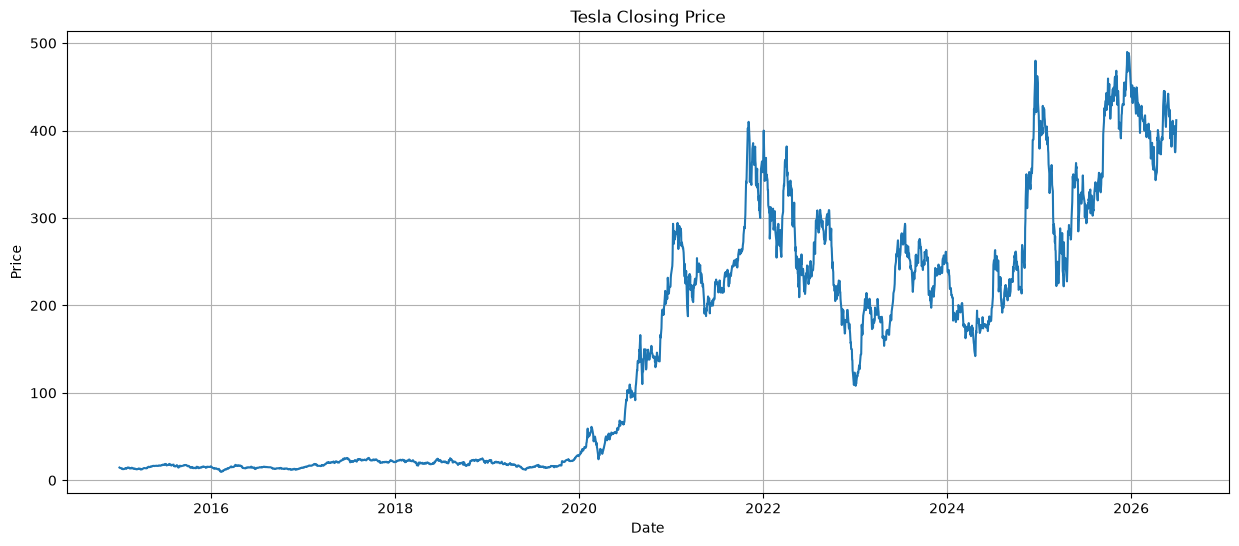

In [4]:
plt.figure(figsize=(15,6))

plt.plot(data)

plt.title("Tesla Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.grid(True)

plt.show()

In [5]:
train_size = int(len(data) * 0.8)

train = data[:train_size]

test = data[train_size:]

print(len(train))

print(len(test))

2310
578


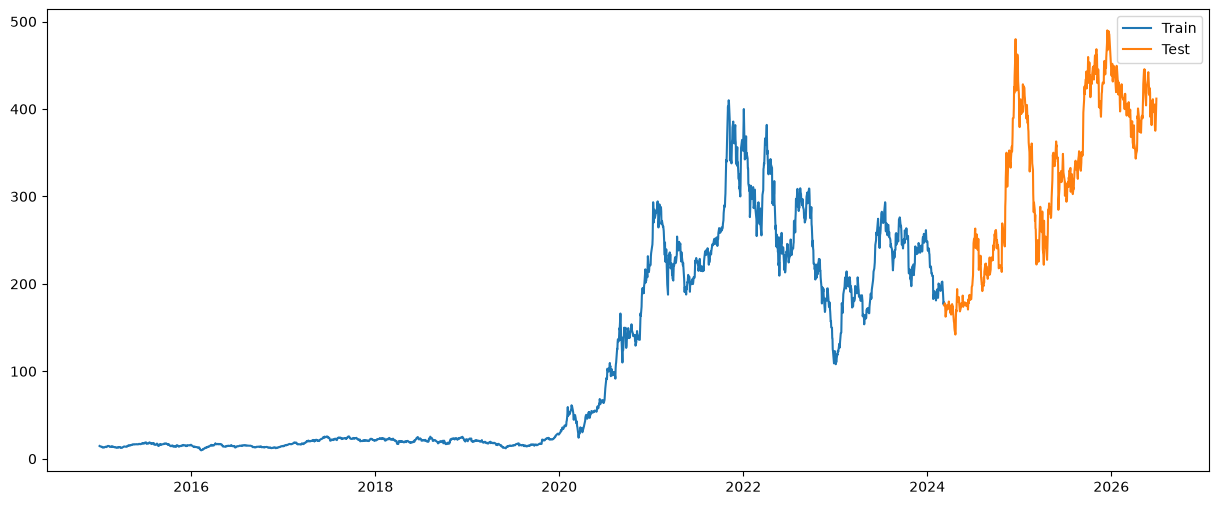

In [6]:
plt.figure(figsize=(15,6))

plt.plot(train, label="Train")

plt.plot(test, label="Test")

plt.legend()

plt.show()

In [7]:
auto_model = auto_arima(

    train,

    seasonal=False,

    trace=True,

    error_action="ignore",

    suppress_warnings=True

)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=14614.905, Time=4.18 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.25 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=0.88 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 7.000 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2310
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7303.183
Date:                Sun, 05 Jul 2026   AIC                          14608.366
Time:                        03:20:59   BIC                          14614.110
Sample:                             0   HQIC                         14610.460
    

In [8]:
model = ARIMA(train, order=(2,1,2))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2310
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -7301.636
Date:                Sun, 05 Jul 2026   AIC                          14613.272
Time:                        03:21:11   BIC                          14641.995
Sample:                             0   HQIC                         14623.742
                               - 2310                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3977      4.892     -0.081      0.935      -9.987       9.191
ar.L2          0.1147      3.096      0.037      0.970      -5.954       6.183
ma.L1          0.3702      4.893      0.076      0.9

In [9]:
forecast = model_fit.forecast(
    steps=len(test)
)

In [10]:
results = pd.DataFrame({

    "Actual": test,

    "Predicted": forecast

})

results.head()

,Actual,Predicted
2024-03-08 00:00:00,175.339996,NaN
2024-03-11 00:00:00,177.770004,NaN
2024-03-12 00:00:00,177.539993,NaN
2024-03-13 00:00:00,169.479996,NaN
2024-03-14 00:00:00,162.500000,NaN


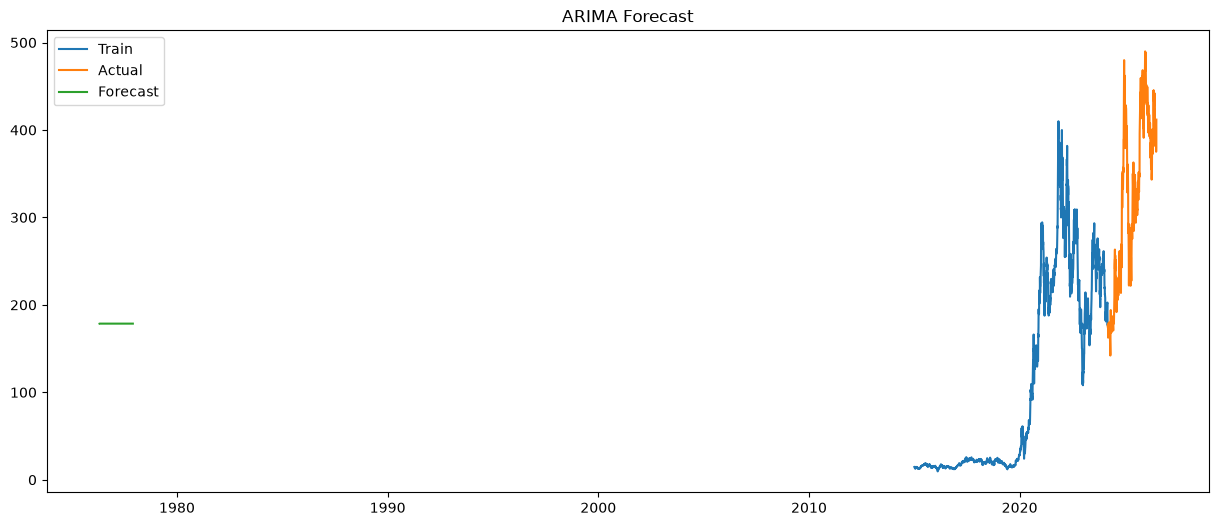

In [11]:
plt.figure(figsize=(15,6))

plt.plot(train, label="Train")

plt.plot(test, label="Actual")

plt.plot(forecast, label="Forecast")

plt.legend()

plt.title("ARIMA Forecast")

plt.show()

In [12]:
mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

mape = mean_absolute_percentage_error(
    test,
    forecast
)

print("MAE :", mae)

print("RMSE:", rmse)

print("MAPE:", mape)

MAE : 147.26221122368528
RMSE: 173.50753398035607
MAPE: 0.39982719025197117


In [13]:
future = model_fit.forecast(steps=30)

future

2310    178.494430
2311    178.589333
2312    178.533743
2313    178.566739
2314    178.547239
2315    178.558780
2316    178.551953
2317    178.555992
2318    178.553602
2319    178.555016
2320    178.554179
2321    178.554674
2322    178.554382
2323    178.554555
2324    178.554452
2325    178.554513
2326    178.554477
2327    178.554498
2328    178.554486
2329    178.554493
2330    178.554489
2331    178.554491
2332    178.554490
2333    178.554491
2334    178.554490
2335    178.554490
2336    178.554490
2337    178.554490
2338    178.554490
2339    178.554490
Name: predicted_mean, dtype: float64

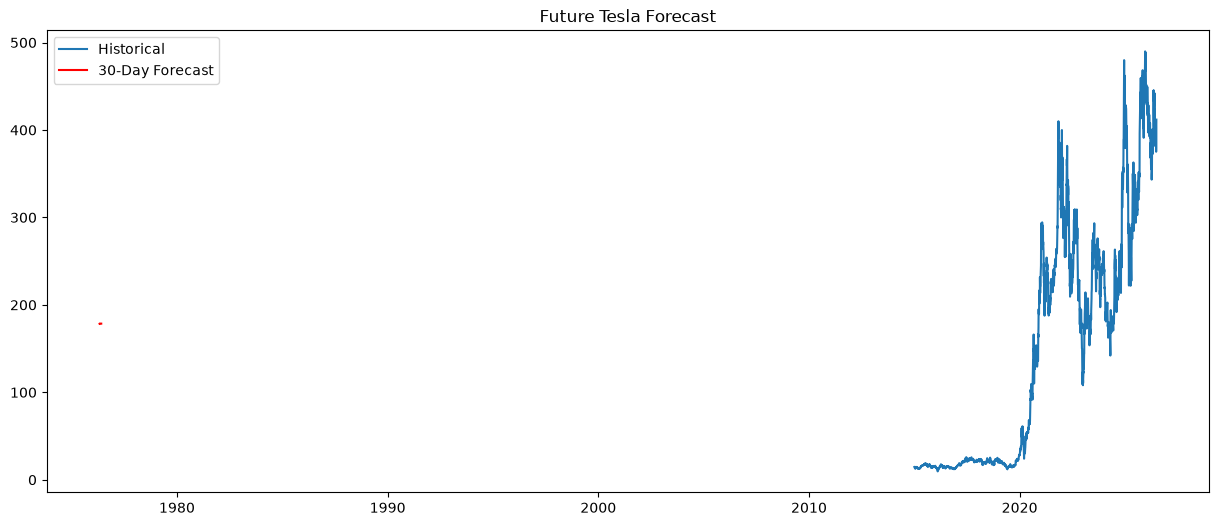

In [14]:
plt.figure(figsize=(15,6))

plt.plot(data, label="Historical")

plt.plot(
    future,
    label="30-Day Forecast",
    color="red"
)

plt.legend()

plt.title("Future Tesla Forecast")

plt.show()

In [15]:
forecast.to_csv("../reports/arima_forecast.csv")

In [1]:
import os

os.makedirs("../models", exist_ok=True)